In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Linear regression with numpy

In this notebook, we will implement a simple linear regression model using NumPy. Linear regression is a fundamental technique in machine learning and statistics used to model the relationship between a dependent variable and an independent variable.  

We will follow these steps to build our model:  
1. **Create a dataset** – Generate synthetic data for our regression task.  
2. **Describe the model** – Define the equation of a simple linear regression.  
3. **Describe the cost function** – Introduce the mean squared error (MSE) to evaluate model performance.  
4. **Gradient descent** – Compute the gradients needed for optimization Optimize the model parameters using gradient descent. 

By the end of this notebook, we will have a working linear regression model implemented from scratch using NumPy.

### 1. Dataset Representation  

We create a dataset $(x, y)$ with $m = 100$ rows, $n = 1$ feature $x$, and $y$ as the target variable.

$$
\begin{array}{|c|c|}
\hline
x & y \\
\hline
x^{(1)} & y^{(1)} \\
x^{(2)} & y^{(2)} \\
\vdots & \vdots \\
x^{(m)} & y^{(m)} \\
\hline
\end{array}
$$


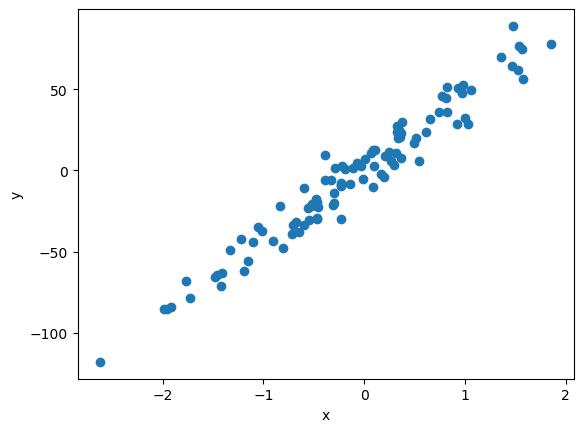

In [27]:
np.random.seed(42)

# Creation of a dataset
x, y = make_regression(n_samples=100, n_features=1, noise=10)

# Visualization of the dataset
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### 2. Describe the model

Our model is represented by the function:  $$f(x) = ax + b$$.

In **matrix form**, we express this as: $$F = X \theta$$

where:  

- $F$ is the predicted output, represented as a column vector:  

  $$
  F = \begin{bmatrix} f(x^{(1)}) \\ f(x^{(2)}) \\ \vdots \\ f(x^{(m)}) \end{bmatrix}
  $$
  with $ \dim(F) = (m \times 1) $.  

- $X$ is the feature matrix, including a column of ones for the bias term:  

  $$
  X = \begin{bmatrix} x^{(1)} & 1 \\ x^{(2)}  & 1 \\ \vdots & \vdots \\ x^{(m)} & 1\end{bmatrix}
  $$
  with $ \dim(X) = m \times (n+1) = m \times 2$

- $\theta$ is the parameter vector:  

  $$
  \theta = \begin{bmatrix} a \\ b \end{bmatrix}
  $$
  with $ \dim(\theta) = (n+1) \times 1 = 2 \times 1$.  

### 3. Describe the Cost Function

The cost function $J$ is given by the mean squared error ([MSE](https://en.wikipedia.org/wiki/Mean_squared_error)):


$$
J(a, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( ax^{(i)} + b - y^{(i)} \right)^2
$$

In **matrix form** :


$$
J(\theta) = \frac{1}{2m} \sum(X.\theta - Y)^2
$$

where $Y$ is a column vector:

$$Y = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots  \\ y^{(m)}\end{bmatrix}$$

### 4. Gradient Descent  

Gradient Descent is an optimization algorithm used to minimize the cost function $J(a, b)$ by iteratively updating the parameters $a$ and $b$ as represented here for parameter $a$ :

![Alt text](gradient_descent.jpg)

The update rules for the parameters are given by:  

$$
a_{i+1} = a_{i} - \alpha \frac{\partial J(a_{i})}{\partial a} \tag{1}
$$

$$
b_{i+1} = b_{i} - \alpha \frac{\partial J(b_{i})}{\partial b} \tag{2}
$$

where:  
- $\alpha$ is the learning rate, controlling the step size and is greater than 0.  
- $\frac{\partial J}{\partial a}$ and $\frac{\partial J}{\partial b}$ are the gradients of the cost function with respect to $a$ and $b$.  

The process is repeated until convergence, ensuring the model parameters minimize the cost function.


The gradients are computed as follows:


$$
\frac{\partial J(a,b)}{\partial a} =
\frac{1}{2m} \sum_{i=1}^{m} \frac{\partial}{\partial a} \left( ax^{(i)} + b - y^{(i)} \right)^2
$$


$$
\quad \quad \quad = \frac{1}{2m} \sum_{i=1}^{m} 2 x^{(i)} \left( ax^{(i)} + b - y^{(i)} \right)
$$


$$
\quad \quad \quad = \frac{1}{m} \sum_{i=1}^{m} \left( ax^{(i)} + b - y^{(i)} \right) x^{(i)}
$$

$$
\frac{\partial J(a,b)}{\partial b} =
\frac{1}{2m} \sum_{i=1}^{m} \frac{\partial}{\partial a} \left( ax^{(i)} + b - y^{(i)} \right)^2
$$


$$
\quad \quad \quad = \frac{1}{2m} \sum_{i=1}^{m} 2 \left( ax^{(i)} + b - y^{(i)} \right)
$$


$$
\quad \quad \quad = \frac{1}{m} \sum_{i=1}^{m} \left( ax^{(i)} + b - y^{(i)} \right)
$$

In **matrix form**, we define $\frac{\partial J(\theta)}{\partial \theta}$ as:

$$
\frac{\partial J(\theta)}{\partial \theta} =
\begin{bmatrix} 
    \frac{\partial J(a,b)}{\partial a} \\ \\ 
    \frac{\partial J(a,b)}{\partial b} 
\end{bmatrix}
= \frac{1}{m}X^T(X\theta - Y)
$$

which is dimension $(n+1) \times 1$

In [24]:
# Dimension verification

print(x.shape)
print(y.shape)

y = y.reshape(y.shape[0],1)

print(x.shape)
print(y.shape)

(100, 1)
(100,)
(100, 1)
(100, 1)


In [20]:
# X matrix

X = np.hstack((x, np.ones(x.shape)))
X.shape

(100, 2)